In [ ]:

import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [ ]:
#Hamiltonian
#number_of_qubits = 2
#m = 0.1

def Get_H(m, number_of_qubits):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 
#H = Get_H(0.2,2)
#I = torch.zeros(2**number_of_qubits,2**number_of_qubits)
#for i in range(2**number_of_qubits):
#    I[i][i] = 1.579100
#H = H +I
#print(H)

In [ ]:
def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I    
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return  matrix_element_iter_new(batch) + matrix_element_xy_new_7(batch) + matrix_element_m(batch)

In [ ]:
number_of_qubits = 14
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)
#basis[basis == 0] = -1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [ ]:
m = 0.1
#H = Get_H(m, number_of_qubits)
#print(H)
torch.set_printoptions(precision=5)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[0]
print(c,m)

NameError: ignored

In [ ]:
def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

In [ ]:
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
#print(sub_batch)
print(good_batch.sum(dim = 1))

7
torch.Size([3432]) torch.Size([3432])
tensor([7., 7., 7.,  ..., 7., 7., 7.])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: This overload of nonzero is deprecated:
	nonzero()
Consider using one of the following signatures instead:
	nonzero(*, bool as_tuple) (Triggered internally at  /pytorch/torch/csrc/utils/python_arg_parser.cpp:882.)
  after removing the cwd from sys.path.


In [ ]:
def make_good_batch(size):
    i = torch.randint(sub_batch.shape[0], (1,))
    #print(i)
    batch = sub_batch[i]
    #print(batch)
    i = torch.randint(sub_batch.shape[0], (size - 1,))
    #print(i)
    for m in range(i.shape[0] , 0, -1):
        #print(sub_batch[i[m-1] + 1].view(1, number_of_qubits))
        batch = torch.cat((batch, sub_batch[i[m-1],:].view(1, number_of_qubits)), axis = 0)
    return batch

In [ ]:
class Net1(nn.Module):
    def __init__(self):
        super(Net1,self).__init__()
        #self.conv0 = nn.Conv1d(1, 50, 10, stride=1) на этом работает хорошо
        #self.conv1 = nn.Conv1d(50, 70, 7, stride=1)
        self.conv0 = nn.Conv1d(1, 25, 10, stride=1, padding = 5)
        self.conv1 = nn.Conv1d(25, 50, 7, stride=1, padding = 4)
        self.conv2 = nn.Conv1d(50, 70, 5, stride=1, padding = 3)
        self.conv3 = nn.Conv1d(70, 80, 4, stride=1, padding = 2)
        self.conv4 = nn.Conv1d(80, 90, 3, stride=1, padding = 1)
        self.conv5 = nn.Conv1d(90, 100, 2, stride=1)
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.bn0 = nn.BatchNorm1d(25)
        self.bn1 = nn.BatchNorm1d(50)
        self.bn2 = nn.BatchNorm1d(70)
        self.bn3 = nn.BatchNorm1d(80)
        self.bn4 = nn.BatchNorm1d(90)
        self.bn5 = nn.BatchNorm1d(100)
        self.pool1 = nn.MaxPool1d(3, stride=2)
        self.avpool1 = nn.AvgPool1d(3, stride = 3)
        
    def forward(self,x):
        
        x = self.conv0(x)
        x = self.tanh(x)
        #x = self.avpool1(x)
        #print(x.shape)
        x = self.bn0(x)

        x = self.conv1(x)
        x = self.tanh(x)
        x = self.bn1(x)
        
        x = self.conv2(x)
        x = self.tanh(x)
        x = self.bn2(x)

        x = self.conv3(x)
        x = self.tanh(x)
        x = self.bn3(x)

        x = self.conv4(x)
        x = self.tanh(x)
        x = self.bn4(x)

        x = self.conv5(x)
        x = self.tanh(x)
        x = self.bn5(x)
        #x = self.pool1(x)
        #print(x.shape)
        
        #x = self.conv2(x)
        #x = self.tanh(x)
        #x = self.pool1(x)
        #x = self.bn2(x)
        return x

In [ ]:
new_class = Net1()
params = list(new_class.parameters())
print(new_class)
print(params[2].shape)

Net1(
  (conv0): Conv1d(1, 25, kernel_size=(10,), stride=(1,), padding=(5,))
  (conv1): Conv1d(25, 50, kernel_size=(7,), stride=(1,), padding=(4,))
  (conv2): Conv1d(50, 70, kernel_size=(5,), stride=(1,), padding=(3,))
  (conv3): Conv1d(70, 80, kernel_size=(4,), stride=(1,), padding=(2,))
  (conv4): Conv1d(80, 90, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv5): Conv1d(90, 100, kernel_size=(2,), stride=(1,))
  (tanh): Tanh()
  (relu): ReLU()
  (bn0): BatchNorm1d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(70, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn5): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): M

In [ ]:
class Net(Net1):
    
    lr = 0.0005
    
    
    N_epochs = 5000
    
    def __init__(self):
        super(Net,self).__init__()
        #self.conv0 = nn.Conv1d(1, 100, 2, stride=1)
        #self.conv1 = nn.Conv1d(100, 100, 2, stride=1)
        #self.conv2 = nn.Conv1d(100, 20, 2, stride=1)
        
        self.Linear2 = nn.Linear(100*(number_of_qubits + 5), 100)
        #self.Linear3 = nn.Linear(100,100)
        self.Linear4 = nn.Linear(100, 1)
        
        self.relu = nn.ReLU()
        self.bn0 = nn.BatchNorm1d(100)
        self.tanh = nn.Tanh()
        
        
    def forward(self,x):
        
        x = new_class(x)
        
        x = torch.reshape(x, (good_vectors.shape[0], 100*(number_of_qubits +5))) 
        x = self.Linear2(x)
        x = self.tanh(x)
        x = self.bn0(x)
        x = self.Linear4(x)
       
        return x
    
    
    
    def loss(self,inp):
        res = torch.matmul(torch.transpose(inp, 0, 1), torch.matmul(H, inp))
        return res
    
    def sample2(self,batch,i):
        accepted = 0
        #count = 0
        for k in range(0,5):
            batch_new = torch.clone(batch)
            dims = torch.arange(batch_size)
            ind = torch.randint(number_of_qubits,(batch_size,))
            batch_new[dims, ind] = 1 - batch_new[dims, ind]

            amplitude = new(batch)
            amplitude_new = new(batch_new)
            #A = torch.reshape((amplitude_new/amplitude)**2,(batch_size,))
            #u = torch.rand((batch_size))
            A = torch.reshape(torch.log(amplitude_new**2 + 1) -  torch.log(amplitude**2 + 1),(batch_size,))
            u = torch.log(torch.rand((batch_size)))
            batch[u < A,:] = batch_new[u < A,:]
            
        return batch
    
    
    def sample(self,batch,i):
        accepted = 0
        #count = 0
        for k in range(0,2):
            batch_new = torch.clone(batch)
            dims = torch.arange(batch_size)
            
            zeros = (batch == 0).nonzero()[:,1].view(batch_size,number_of_qubits - sum_spin )
            ones = (batch == 1).nonzero()[:,1].view(batch_size,number_of_qubits - sum_spin )
            ind = torch.randint(number_of_qubits - sum_spin,(batch_size,))
            ind2 = torch.randint(number_of_qubits - sum_spin,(batch_size,))
            i = torch.arange(0,batch_size,1)
            ind = zeros[i, ind]
            ind2 = ones[i, ind2]  
            #print((ind == ind2).nonzero())
            
            batch_new[dims,0, ind] = 1 - batch_new[dims,0, ind]
            batch_new[dims,0, ind2] = 1 - batch_new[dims,0, ind2]
            #batch_new = torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

            amplitude = new(batch)
            amplitude_new = new(batch_new)
            
            A = torch.reshape(torch.log(amplitude_new**2 + 1) -  torch.log(amplitude**2 + 1),(batch_size,))
            
            u = torch.log(torch.rand((batch_size)))
            batch[u < A,:] = batch_new[u < A,:]
            
        return batch
    
    def loss2(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        epsilon = 0.00001
        psi = psi/(psi.norm())
        
        #print(out.shape)
        out= torch.reshape(out, (batch_size, number_of_qubits)).to(device)
        
        M = matrix(out).to(device)
        E = torch.matmul(torch.transpose(psi, 0, 1), torch.matmul(M, psi))
        #print(E)
        return E
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam([
                {'params': new_class.parameters()},
                {'params': self.parameters(), 'lr': self.lr}
            ], lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.5) 
        distance = []
        count = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2000,10000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            
            #inp = self.sample(inp,i)
            loss_curr = self.loss2(inp)
            
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).cpu().detach().numpy())# To stop a tensor from tracking history, you can call .detach() 
            count += 1
            if count == 100:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                count = 0
        return distance

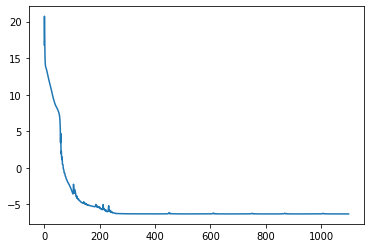


 22%|██▏       | 1100/5000 [06:54<28:11,  2.31it/s]

tensor([[-6.28750]], device='cuda:0', grad_fn=<MmBackward>)



 23%|██▎       | 1132/5000 [07:06<24:05,  2.68it/s]

KeyboardInterrupt: ignored

In [ ]:
new_class = Net1().to(device)
new = Net().to(device)
print(new)
m = 0.1

pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch
batch = batch.unsqueeze(1).to(device)
print(batch.shape)


dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))

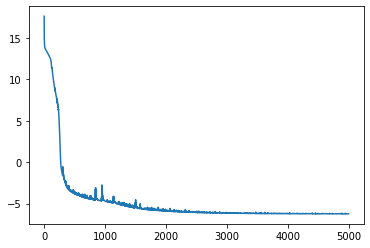

100%|██████████| 5000/5000 [28:45<00:00,  2.90it/s]

tensor([[-6.23166]], device='cuda:0', grad_fn=<MmBackward>)


NameError: ignored

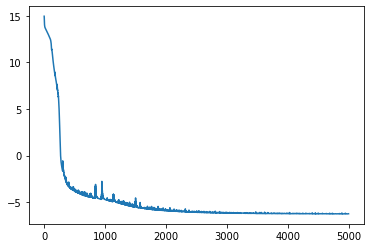

In [ ]:
new_class = Net1().to(device)
new = Net().to(device)
print(new)
m = 0.1

pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch
batch = batch.unsqueeze(1).to(device)
print(batch.shape)


dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))

In [ ]:
 m = nn.MaxPool1d(3, stride=2)
>>> input = torch.randn(20, 16, 5)
>>> output = m(input)
print(output.shape)

torch.Size([20, 16, 2])


In [ ]:
torch.set_printoptions(precision=5)
H = Get_H(m, number_of_qubits)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(2**number_of_qubits)
#min_vector = eig_vector[:,m].reshape(1,2**number_of_qubits)


torch.Size([252, 1, 10])
torch.Size([252, 1])
tensor(1.00000)
tensor(1.00000) tensor(1.00000)


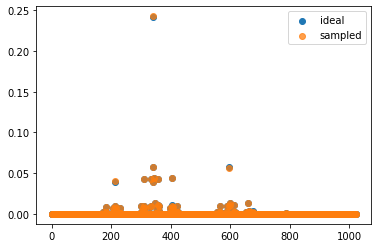

In [ ]:
basiss = torch.clone(good_batch).unsqueeze(1).to(device)
print(basiss.shape)
T = new(basiss).detach().cpu()
T = (T/T.norm()).view(T.shape[0], -1)
print(T.shape)
my_way = torch.zeros(2**number_of_qubits, 1)
my_way[good_vectors, :] = T[i, :]
#print(my_way)
#print(torch.matmul(torch.transpose(T.view(basis.shape[0],1), 0, 1), torch.matmul(H, T)))
import matplotlib.colors as mcolors
a = R**2
print(my_way.norm())
x = np.arange(0,2**number_of_qubits)
y = np.random.randint(1, 20, size = 2**number_of_qubits)

z = torch.zeros(2**number_of_qubits)
#z = T**2
z = my_way**2
print(z.sum(), a.sum())
fig, ax = plt.subplots()
ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

In [ ]:
number_of_qubits = 14
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)
#basis[basis == 0] = -1
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch
#print(sub_batch)
#print(good_batch.sum(dim = 1))

def make_good_batch(size):
    i = torch.randint(sub_batch.shape[0], (1,))
    #print(i)
    batch = sub_batch[i]
    #print(batch)
    i = torch.randint(sub_batch.shape[0], (size - 1,))
    #print(i)
    for m in range(i.shape[0] , 0, -1):
        #print(sub_batch[i[m-1] + 1].view(1, number_of_qubits))
        batch = torch.cat((batch, sub_batch[i[m-1],:].view(1, number_of_qubits)), axis = 0)
    return batch

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
7
torch.Size([3432]) torch.Size([3432])


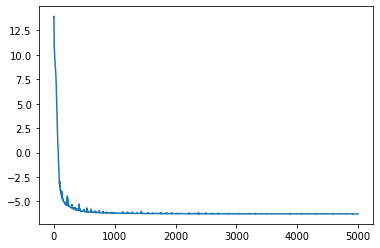


100%|██████████| 5000/5000 [29:47<00:00,  2.80it/s]

tensor([[-6.28551]], device='cuda:0', grad_fn=<MmBackward>)


NameError: ignored

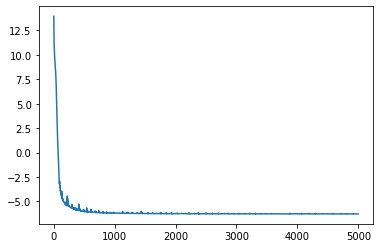

In [ ]:
#new_class = Net1()
new = Net().to(device)
print(new)
m = 0.1

pick = math.ceil((2**number_of_qubits*0.33))
batch_size = good_batch.shape[0]
batch = good_batch
#batch = make_good_batch(2)
batch = batch.unsqueeze(1).to(device)
print(batch.shape)

dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))